In [27]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    recall_score,
    precision_score
)

import jax
import jax.numpy as jnp
import optax
import chex
from flax import nnx
import orbax.checkpoint as ocp

In [2]:
# paleta para as duas classes (scatter plots)
CLASS_CMAP = LinearSegmentedColormap.from_list(
    "class_cmap", ["#4682B4", "#E8743B"], N=2
)

# paleta divergente para o mapa de probabilidades (azul -> branco -> laranja)
PROB_CMAP = LinearSegmentedColormap.from_list(
    "prob_cmap", ["#4682B4", "#F5F5F5", "#E8743B"], N=256
)

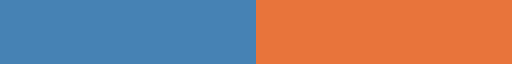

In [3]:
CLASS_CMAP

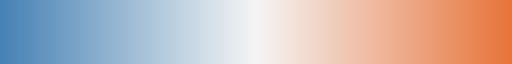

In [4]:
PROB_CMAP

In [5]:
# settings
TEST_SIZE = 0.3
SEED = 42
NOISE = 0.07
N = 500_000

In [6]:
X, y = make_moons(n_samples=N, random_state=SEED, noise=NOISE)
X, y = jnp.array(X), jnp.array(y.reshape(-1, 1))

# chex: garante que os shapes batem com o esperado antes de seguir
chex.assert_shape(X, (N, 2))
chex.assert_shape(y, (N, 1))

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=SEED, test_size=TEST_SIZE, shuffle=True
)

chex.assert_equal(X_train.shape[0], y_train.shape[0])
chex.assert_equal(X_test.shape[0], y_test.shape[0])

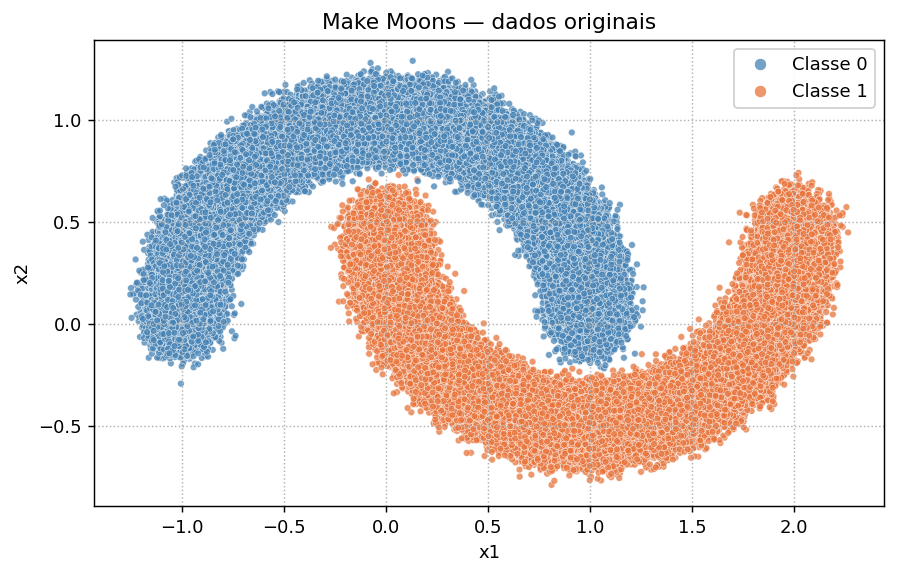

In [8]:
fig, ax = plt.subplots(figsize=(7, 5.5), dpi=130)
scatter = ax.scatter(
    X[:, 0], X[:, 1],
    c=np.array(y).ravel(),
    cmap=CLASS_CMAP,
    s=14,
    alpha=0.75,
    edgecolors="white",
    linewidths=0.3,
)
handles, _ = scatter.legend_elements()
ax.legend(handles, ["Classe 0", "Classe 1"], loc="upper right", frameon=True, framealpha=0.9)
ax.set_title("Make Moons — dados originais")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_aspect("equal")
ax.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

In [9]:
class MLP(nnx.Module):
    def __init__(self, hidden_dim: int, *, rngs: nnx.Rngs):
        self.linear1 = nnx.Linear(2, hidden_dim, rngs=rngs)
        self.linear2 = nnx.Linear(hidden_dim, 1, rngs=rngs)

    def __call__(self, x):
        x = self.linear1(x)
        x = nnx.relu(x)
        x = self.linear2(x)
        return x

In [10]:
HIDDEN_DIM = 32

model = MLP(HIDDEN_DIM, rngs=nnx.Rngs(SEED))

# chex: confere se os parâmetros do modelo nascem sem NaN/Inf
chex.assert_tree_all_finite(nnx.state(model, nnx.Param))

In [11]:
def loss_fn(model, x, y):
    chex.assert_equal(x.shape[0], y.shape[0])  # mesmo numero de exemplos
    logits = model(x)
    loss = optax.sigmoid_binary_cross_entropy(logits, y)
    return loss.mean()

In [12]:
LR = 1e-3

optimizer = nnx.Optimizer(model, optax.adam(LR), wrt=nnx.Param)

In [13]:
@nnx.jit
def train_step(model, optimizer, x, y):
    loss, grads = nnx.value_and_grad(loss_fn)(model, x, y)
    optimizer.update(grads)
    return loss

In [14]:
N_EPOCHS = 5000
losses = []

for epoch in range(N_EPOCHS):
    loss = train_step(model, optimizer, X_train, y_train)
    losses.append(float(loss))

    if epoch % 100 == 0:
        print(f"epoch {epoch:4d} | loss {loss:.4f}")

# chex: garante que os parâmetros continuam saudáveis após o treino
chex.assert_tree_all_finite(nnx.state(model, nnx.Param))

epoch    0 | loss 0.8903
epoch  100 | loss 0.4920
epoch  200 | loss 0.3436
epoch  300 | loss 0.2844
epoch  400 | loss 0.2522
epoch  500 | loss 0.2325
epoch  600 | loss 0.2183
epoch  700 | loss 0.2051
epoch  800 | loss 0.1910
epoch  900 | loss 0.1756
epoch 1000 | loss 0.1595
epoch 1100 | loss 0.1433
epoch 1200 | loss 0.1277
epoch 1300 | loss 0.1132
epoch 1400 | loss 0.1000
epoch 1500 | loss 0.0881
epoch 1600 | loss 0.0777
epoch 1700 | loss 0.0685
epoch 1800 | loss 0.0605
epoch 1900 | loss 0.0536
epoch 2000 | loss 0.0476
epoch 2100 | loss 0.0424
epoch 2200 | loss 0.0379
epoch 2300 | loss 0.0340
epoch 2400 | loss 0.0306
epoch 2500 | loss 0.0276
epoch 2600 | loss 0.0250
epoch 2700 | loss 0.0227
epoch 2800 | loss 0.0202
epoch 2900 | loss 0.0177
epoch 3000 | loss 0.0159
epoch 3100 | loss 0.0144
epoch 3200 | loss 0.0131
epoch 3300 | loss 0.0120
epoch 3400 | loss 0.0110
epoch 3500 | loss 0.0101
epoch 3600 | loss 0.0093
epoch 3700 | loss 0.0086
epoch 3800 | loss 0.0080
epoch 3900 | loss 0.0074


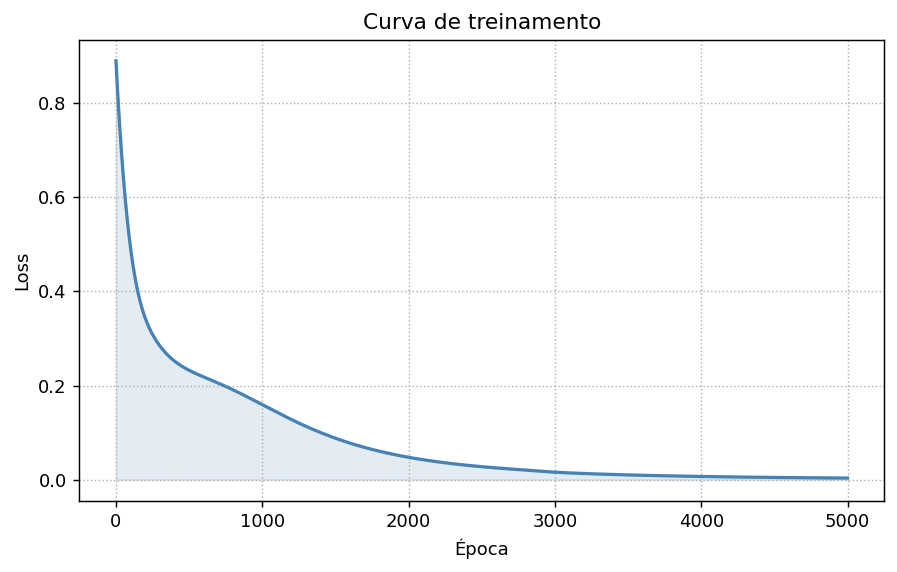

In [28]:
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=130)
ax.plot(losses, color="#4682B4", linewidth=1.8)
ax.fill_between(range(len(losses)), losses, alpha=0.15, color="#4682B4")
ax.set_title("Curva de treinamento")
ax.set_xlabel("Época")
ax.set_ylabel("Loss")
ax.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

In [17]:
import os

CKPT_DIR = os.path.abspath("checkpoints/mlp_moons")
os.makedirs(os.path.dirname(CKPT_DIR), exist_ok=True)

# separa a estrutura (graphdef) do estado de parâmetros (state)
graphdef, state = nnx.split(model)

checkpointer = ocp.StandardCheckpointer()

# orbax exige que o diretório de destino não exista antes do save
if os.path.exists(CKPT_DIR):
    checkpointer.save(CKPT_DIR, state, force=True)
else:
    checkpointer.save(CKPT_DIR, state)

checkpointer.wait_until_finished()
print(f"checkpoint salvo em: {CKPT_DIR}")

checkpoint salvo em: /home/agent_smith/Documents/DeepLearningEngineering/JaxFlaxOptimax/checkpoints/mlp_moons


In [18]:
restored_state = checkpointer.restore(CKPT_DIR, target=state)

# chex: confirma que o estado restaurado é idêntico ao treinado
chex.assert_trees_all_close(state, restored_state)
print("checkpoint restaurado e validado com sucesso (chex.assert_trees_all_close)")

# reconstrói o modelo a partir da estrutura + estado restaurado
model = nnx.merge(graphdef, restored_state)

checkpoint restaurado e validado com sucesso (chex.assert_trees_all_close)


In [19]:
y_pred_logits = model(X_test)
probs = jax.nn.sigmoid(y_pred_logits)
y_pred = (probs > 0.5).astype(int)

chex.assert_equal_shape([y_pred, y_test])

In [22]:
print(f"Recall: {recall_score(y_test, y_pred):.4f}\n")

Recall: 0.9999



In [23]:
print(f"Precision: {precision_score(y_test, y_pred):.4f}\n")

Precision: 0.9998



In [24]:
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

Acurácia: 0.9999

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     75146
           1       1.00      1.00      1.00     74854

    accuracy                           1.00    150000
   macro avg       1.00      1.00      1.00    150000
weighted avg       1.00      1.00      1.00    150000



In [25]:
# limites do gráfico, com margem extra para o contorno respirar
x_min, x_max = X_test[:, 0].min() - 0.3, X_test[:, 0].max() + 0.3
y_min, y_max = X_test[:, 1].min() - 0.3, X_test[:, 1].max() + 0.3

# grid mais fino (250x250) para um gradiente mais suave
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 250),
    np.linspace(y_min, y_max, 250)
)
grid = np.c_[xx.ravel(), yy.ravel()]

logits_grid = model(jnp.array(grid))
probs_grid = jax.nn.sigmoid(logits_grid)

chex.assert_shape(probs_grid, (grid.shape[0], 1))

probs_map = np.array(probs_grid).reshape(xx.shape)

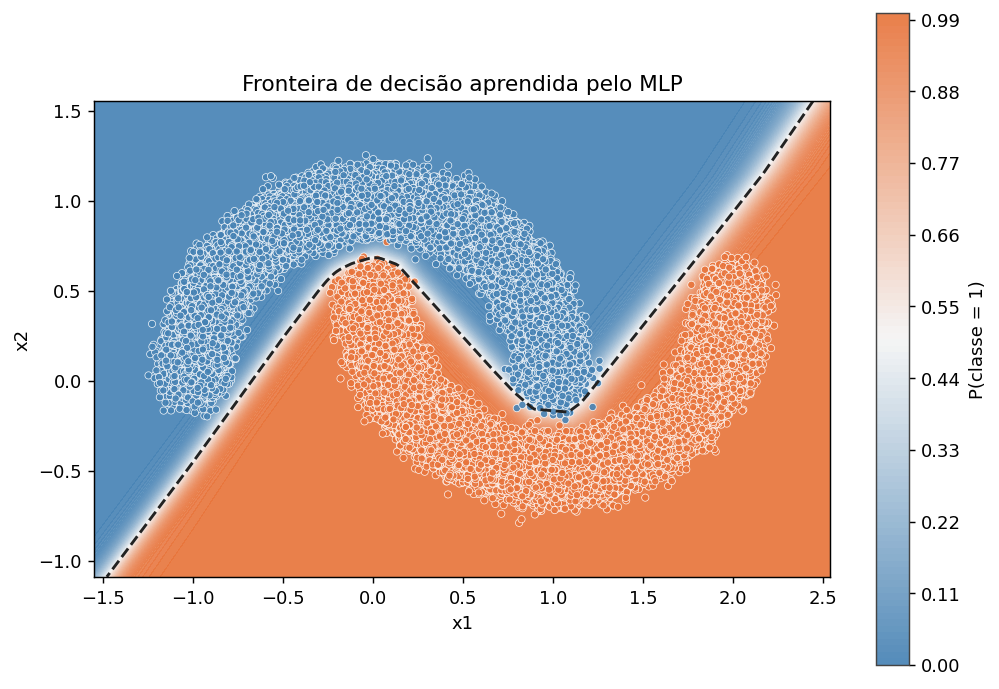

In [26]:
fig, ax = plt.subplots(figsize=(8, 6.2), dpi=130)

# mapa de probabilidade contínuo, com muitos níveis para suavidade
cf = ax.contourf(
    xx, yy, probs_map,
    levels=100,
    cmap=PROB_CMAP,
    alpha=0.92,
    vmin=0, vmax=1,
)

# fronteira de decisão (P = 0.5) destacada
ax.contour(
    xx, yy, probs_map,
    levels=[0.5],
    colors="#222222",
    linewidths=1.6,
    linestyles="--",
)

# pontos reais de teste sobrepostos
ax.scatter(
    X_test[:, 0], X_test[:, 1],
    c=np.array(y_test).ravel(),
    cmap=CLASS_CMAP,
    s=16,
    edgecolors="white",
    linewidths=0.4,
    alpha=0.9,
)

cbar = plt.colorbar(cf, ax=ax, label="P(classe = 1)", shrink=0.85)
cbar.outline.set_edgecolor("#444444")

ax.set_title("Fronteira de decisão aprendida pelo MLP")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()